# Blocks containing tests for synthetic data

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))


#import data processing from the utils directory
from utils import data_processing as dp
from utils import pair_methods as pm

In [3]:
#generate synthetic data
syntehtic_file_path = './synthetic_data'

dp.generate_synthetic_permutation_data(output_dir=syntehtic_file_path)

Synthetic data saved in './synthetic_data/'


In [7]:
#functions for testing the generated synthetic data
import numpy as np
def permutation_vector_to_matrix(perm): # convert permutation lists(from .json) to permutation matrices
    
    n = len(perm)
    matrix = np.zeros((n, n))
    for i, j in enumerate(perm):
        matrix[i, j] = 1
    return matrix
def compute_difference_matrix(true_matrix, noisy_matrix): # compute the difference between the ground truth and the noisy matrices
    return np.abs(true_matrix - noisy_matrix)
import matplotlib.pyplot as plt

def visualize_permutation_comparison(P_true, P_noisy, P_diff, title_prefix="P_ij"):
    """
    Show the true, noisy, and difference matrices side by side.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(P_true, cmap="gray")
    axes[0].set_title(f"{title_prefix} (Ground Truth)")

    axes[1].imshow(P_noisy, cmap="gray")
    axes[1].set_title(f"{title_prefix} (Noisy)")

    axes[2].imshow(P_diff, cmap="hot")
    axes[2].set_title(f"{title_prefix} (Difference)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def print_permutation_matrices(gt_perms, pairwise_perms, i, j): #print the matrices in numerical form
    P_i = permutation_vector_to_matrix(gt_perms[i])
    P_j = permutation_vector_to_matrix(gt_perms[j])
    P_j_inv = np.linalg.inv(P_j)
    P_ij_true = P_i @ P_j_inv
    P_ij_noisy = np.array(pairwise_perms[f"{i}_{j}"])

    print(f"\n=== Ground Truth Permutation P_{i}{j} ===")
    print(np.round(P_ij_true).astype(int))

    print(f"\n=== Noisy Pairwise Permutation P_{i}{j} ===")
    print(P_ij_noisy.astype(int))

    print(f"\n=== Difference Matrix (|Noisy - True|) ===")
    print(np.abs(P_ij_true - P_ij_noisy).astype(int))

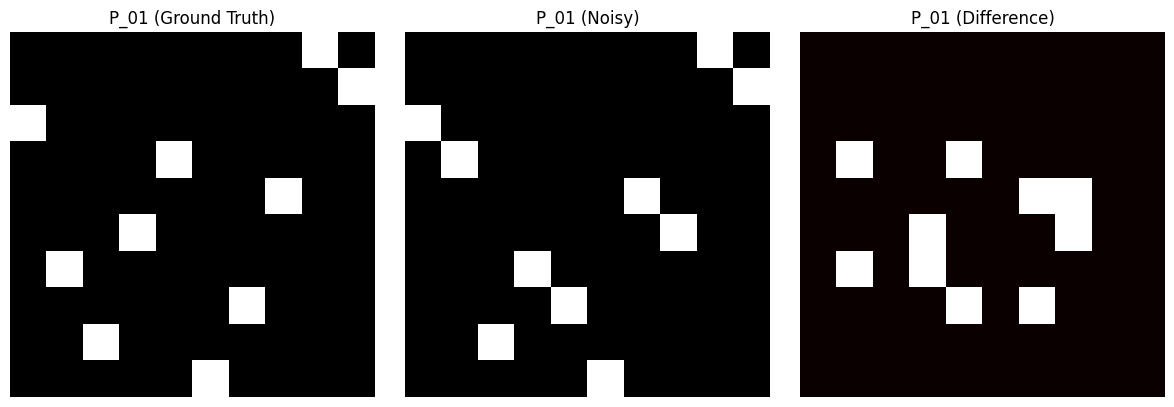

In [ ]:
import json
# Load data
with open("synthetic_data/ground_truth_permutations.json") as f:
    gt_perms = json.load(f)

with open("synthetic_data/pairwise_permutations.json") as f:
    pairwise_perms = json.load(f)

# Choose pair (i, j)
i, j = 0, 1
P_i = permutation_vector_to_matrix(gt_perms[i])
P_j = permutation_vector_to_matrix(gt_perms[j])
P_j_inv = np.linalg.inv(P_j)
P_ij_true = P_i @ P_j_inv

P_ij_noisy = np.array(pairwise_perms[f"{i}_{j}"])
P_diff = compute_difference_matrix(P_ij_true, P_ij_noisy)

# Visualize
visualize_permutation_comparison(P_ij_true, P_ij_noisy, P_diff, title_prefix=f"P_{i}{j}")


In [11]:
#print the matrices
num_agents = 5
for i in range(num_agents):
    for j in range(i+1, num_agents):
        print_permutation_matrices(gt_perms,pairwise_perms,i,j)



=== Ground Truth Permutation P_01 ===
[[0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]

=== Noisy Pairwise Permutation P_01 ===
[[0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]]

=== Difference Matrix (|Noisy - True|) ===
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 1 0 0]
 [0 1 0 1 0 0 0 0 0 0]
 [0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

=== Ground Truth Permutation P_02 ===
[[0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 